# 02 日曲线 PCA + 双岭回归

负荷与光伏分别使用独立的 PCA 和岭回归。两个模型都使用历史日曲线的 PCA 得分、1/7 日滞后及近 7 日均值；负荷的日历变量为“周五或周六 / 其他日期”两类及年周期，光伏保留星期特征但不输入年周期。输出分别为下一日负荷和光伏的 PCA 得分，再重建 144 点曲线。概率场景由历史整日成对残差生成。

所有结果只保存在 Notebook 输出中，不写出图片、表格或缓存文件。预测评价期为 2025-02-01 至 2025-12-31；题目给定的初始储能为 6000 kWh，但本 Notebook 只评价预测层，因此不计算调度费用。

In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from IPython.display import display

ROOT = Path.cwd()
while not (ROOT / "C题.md").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = pd.read_csv(ROOT / "Data_preprocessed/processed/actuals_10min.csv", encoding="utf-8-sig")
DATES = pd.DatetimeIndex(pd.to_datetime(DATA["source_date"].drop_duplicates()))
LOAD = DATA["load_kw"].to_numpy(float).reshape(-1, 144)
PV = DATA["pv_kw"].to_numpy(float).reshape(-1, 144)
EVAL_START = pd.Timestamp("2025-02-01")
EVAL_IDX = np.where(DATES >= EVAL_START)[0]
SLOTS = np.arange(144)
INITIAL_STORAGE_KWH = 6000.0  # 题目给定的 2025-01-01 00:00 初始储能
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": .25})

def crps_ensemble(samples, actual):
    # CRPS = E|X-y| - 1/2 E|X-X'|；排序形式避免构造 S×S 矩阵
    z = np.sort(samples, axis=0)
    s = len(z)
    w = (2*np.arange(1, s+1)-1-s)[:, None]
    return np.abs(z-actual).mean(axis=0) - (w*z).sum(axis=0)/(s*s)

def evaluate_forecast(centres_load, centres_pv, scenario_days):
    rows, q10s, q90s, q05s, q95s = [], [], [], [], []
    for d in EVAL_IDX:
        cnet = centres_load[d] - centres_pv[d]
        actual = LOAD[d] - PV[d]
        scen = scenario_days[d]
        q05, q10, q90, q95 = np.quantile(scen, [.05, .10, .90, .95], axis=0)
        rows.append({
            "date": DATES[d],
            "mae_kw": np.abs(cnet-actual).mean(),
            "rmse_kw": np.sqrt(np.mean((cnet-actual)**2)),
            "crps_kw": crps_ensemble(scen, actual).mean(),
            "cover80": np.mean((actual >= q10) & (actual <= q90)),
            "cover90": np.mean((actual >= q05) & (actual <= q95)),
            "width80_kw": np.mean(q90-q10),
            "width90_kw": np.mean(q95-q05),
        })
        q10s.append(q10); q90s.append(q90); q05s.append(q05); q95s.append(q95)
    daily = pd.DataFrame(rows)
    summary = pd.DataFrame({
        "metric": ["MAE (kW)", "RMSE (kW)", "CRPS (kW)", "80% coverage", "90% coverage", "80% width (kW)", "90% width (kW)"],
        "value": [daily.mae_kw.mean(), daily.rmse_kw.mean(), daily.crps_kw.mean(), daily.cover80.mean(), daily.cover90.mean(), daily.width80_kw.mean(), daily.width90_kw.mean()]
    })
    bands = {"q10": np.array(q10s), "q90": np.array(q90s), "q05": np.array(q05s), "q95": np.array(q95s)}
    return daily, summary, bands

def plot_diagnostics(model_name, centres_load, centres_pv, scenario_days, daily, bands):
    # 指定日概率扇形图
    d = int(np.where(DATES == pd.Timestamp("2025-06-21"))[0][0])
    x = SLOTS / 6
    scen = scenario_days[d]
    q05, q10, q90, q95 = np.quantile(scen, [.05, .10, .90, .95], axis=0)
    center = centres_load[d] - centres_pv[d]
    actual = LOAD[d] - PV[d]
    fig, ax = plt.subplots()
    ax.fill_between(x, q05, q95, alpha=.18, label="90% interval")
    ax.fill_between(x, q10, q90, alpha=.28, label="80% interval")
    ax.plot(x, actual, color="black", lw=1.5, label="actual net load")
    ax.plot(x, center, color="tab:red", lw=1.2, label="center forecast")
    ax.set(title=f"{model_name}: 2025-06-21", xlabel="hour", ylabel="kW")
    ax.legend(ncol=2); plt.show()

    monthly = daily.assign(month=daily.date.dt.month).groupby("month")[["mae_kw", "crps_kw"]].mean()
    monthly.plot(marker="o", title=f"{model_name}: monthly forecast scores", ylabel="kW")
    plt.show()

    cov = [daily.cover80.mean(), daily.cover90.mean()]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(["80% interval", "90% interval"], cov, color=["#4c78a8", "#72b7b2"])
    ax.scatter([0, 1], [.8, .9], color="black", zorder=3, label="nominal")
    ax.set_ylim(0, 1); ax.set_ylabel("empirical coverage"); ax.set_title(f"{model_name}: calibration")
    ax.legend(); plt.show()


In [2]:

def pca_basis(curves, k):
    mu = curves.mean(axis=0)
    _, _, vt = np.linalg.svd(curves-mu, full_matrices=False)
    return mu, vt[:k]

def history_score_features(scores_l, scores_p, j):
    return np.r_[scores_l[j-1], scores_p[j-1],
                 scores_l[j-7], scores_p[j-7],
                 scores_l[j-7:j].mean(axis=0), scores_p[j-7:j].mean(axis=0)]

def load_features(scores_l, scores_p, dates, j):
    # 以“周五+周六 / 其他日期”两类 one-hot 取代原 7 维星期特征。
    is_fri_sat = int(dates[j].weekday() in (4, 5))
    day_group = np.eye(2)[is_fri_sat]
    doy = dates[j].dayofyear
    annual_cycle = [np.sin(2*np.pi*doy/365.25), np.cos(2*np.pi*doy/365.25)]
    return np.r_[day_group, annual_cycle, history_score_features(scores_l, scores_p, j)]

def pv_features(scores_l, scores_p, dates, j):
    # 光伏保留原 7 维星期特征，但不使用年周期正余弦。
    dow = np.eye(7)[dates[j].weekday()]
    return np.r_[dow, history_score_features(scores_l, scores_p, j)]

centres_load = np.full_like(LOAD, np.nan)
centres_pv = np.full_like(PV, np.nan)
scenario_days, residual_bank = {}, []
start_day, window = 14, 120
k_load, k_pv = 6, 6
alpha_load, alpha_pv = 10.0, 10.0
last_components = None

for d in range(start_day, len(DATES)):
    h0 = max(0, d-window)
    mu_l, phi_l = pca_basis(LOAD[h0:d], k_load)
    mu_p, phi_p = pca_basis(PV[h0:d], k_pv)
    score_l = (LOAD-mu_l) @ phi_l.T
    score_p = (PV-mu_p) @ phi_p.T
    train_days = np.arange(max(h0+7, 7), d)
    X_load = np.vstack([load_features(score_l, score_p, DATES, j) for j in train_days])
    X_pv = np.vstack([pv_features(score_l, score_p, DATES, j) for j in train_days])
    model_load = make_pipeline(StandardScaler(), Ridge(alpha=alpha_load)).fit(
        X_load, score_l[train_days])
    model_pv = make_pipeline(StandardScaler(), Ridge(alpha=alpha_pv)).fit(
        X_pv, score_p[train_days])
    pred_score_l = model_load.predict(
        load_features(score_l, score_p, DATES, d)[None, :])[0]
    pred_score_p = model_pv.predict(
        pv_features(score_l, score_p, DATES, d)[None, :])[0]
    centres_load[d] = np.maximum(mu_l + pred_score_l @ phi_l, 0)
    centres_pv[d] = np.maximum(mu_p + pred_score_p @ phi_p, 0)
    last_components = (phi_l.copy(), phi_p.copy())

    if residual_bank:
        err_l = np.array([x[0] for x in residual_bank[-28:]])
        err_p = np.array([x[1] for x in residual_bank[-28:]])
        ls = np.maximum(centres_load[d][None, :] + err_l, 0)
        ps = np.maximum(centres_pv[d][None, :] + err_p, 0)
        scenario_days[d] = ls - ps
    residual_bank.append((LOAD[d]-centres_load[d], PV[d]-centres_pv[d]))

daily, summary, bands = evaluate_forecast(centres_load, centres_pv, scenario_days)


## PCA 主成分数量选择

以下使用评价期开始前最近 120 天作为代表性窗口，分别检查负荷与光伏 PCA。碎石图和累计方差解释率反映各主成分保留的信息量；按时间顺序留出窗口末尾 20% 的日期，比较不同主成分数量对未参与拟合日曲线的重建 RMSE。虚线标出本文采用的 6 个主成分。

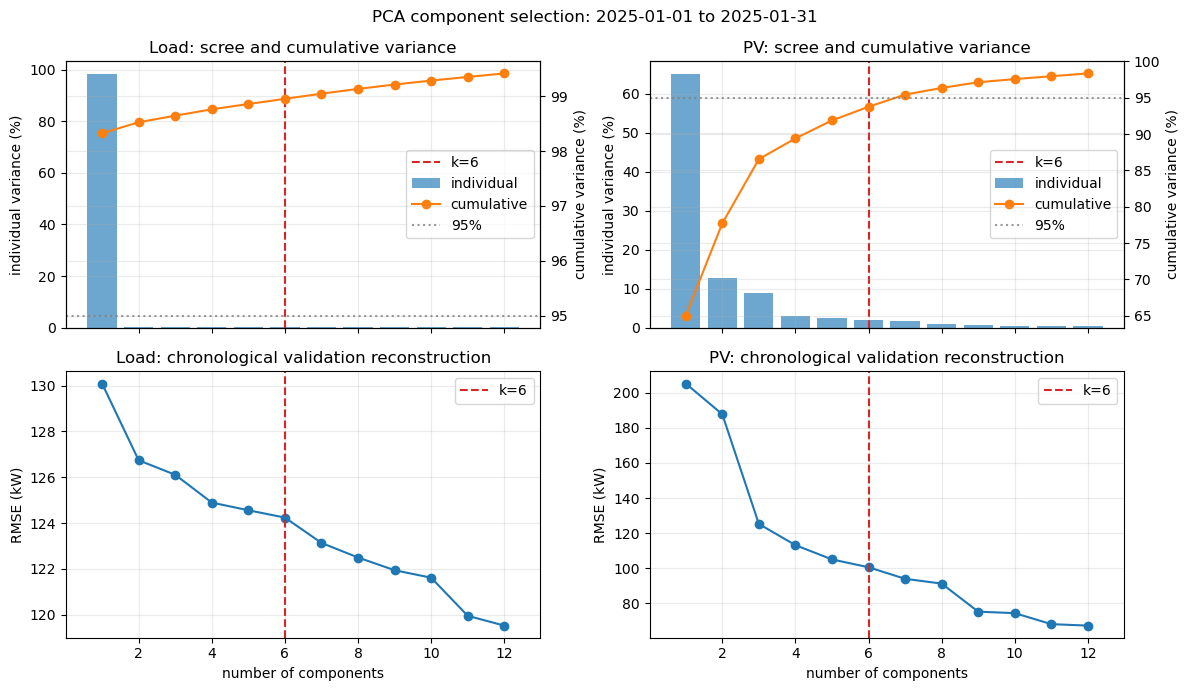

,series,selected_k,cumulative_variance_at_selected_k,validation_rmse_at_selected_k_kw,validation_rmse_at_12_kw
0,Load,6,0.9895,124.2403,119.5263
1,PV,6,0.9376,100.5010,67.2065


In [3]:
def pca_selection_diagnostics(curves, max_k=12):
    # 完整代表窗口用于计算方差解释率
    centered = curves - curves.mean(axis=0)
    _, singular_values, _ = np.linalg.svd(centered, full_matrices=False)
    explained_ratio = singular_values**2 / np.sum(singular_values**2)

    # 按时间留出末尾 20%，检查主成分对新日期的曲线重建能力
    split = int(len(curves) * 0.8)
    train, valid = curves[:split], curves[split:]
    mu = train.mean(axis=0)
    _, _, basis = np.linalg.svd(train - mu, full_matrices=False)
    reconstruction_rmse = []
    for k in range(1, max_k + 1):
        scores = (valid - mu) @ basis[:k].T
        reconstructed = mu + scores @ basis[:k]
        reconstruction_rmse.append(np.sqrt(np.mean((valid - reconstructed)**2)))
    return explained_ratio[:max_k], np.array(reconstruction_rmse)

reference_end = EVAL_IDX[0]
reference_start = max(0, reference_end - window)
reference_sets = {
    'Load': LOAD[reference_start:reference_end],
    'PV': PV[reference_start:reference_end],
}
max_k = 12
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex='col')
selection_rows = []

for col, (name, curves) in enumerate(reference_sets.items()):
    explained, reconstruction_rmse = pca_selection_diagnostics(curves, max_k)
    components = np.arange(1, max_k + 1)
    selected_k = k_load if name == 'Load' else k_pv

    ax = axes[0, col]
    ax.bar(components, explained * 100, alpha=.65, label='individual')
    ax.set(title=f'{name}: scree and cumulative variance', ylabel='individual variance (%)')
    ax.axvline(selected_k, color='tab:red', ls='--', label=f'k={selected_k}')
    ax2 = ax.twinx()
    ax2.plot(components, np.cumsum(explained) * 100, color='tab:orange', marker='o', label='cumulative')
    ax2.axhline(95, color='grey', ls=':', alpha=.8, label='95%')
    ax2.set_ylabel('cumulative variance (%)')
    handles = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labels = ax.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax.legend(handles, labels, loc='center right')

    ax = axes[1, col]
    ax.plot(components, reconstruction_rmse, marker='o')
    ax.axvline(selected_k, color='tab:red', ls='--', label=f'k={selected_k}')
    ax.set(title=f'{name}: chronological validation reconstruction', xlabel='number of components', ylabel='RMSE (kW)')
    ax.legend()

    selection_rows.append({
        'series': name,
        'selected_k': selected_k,
        'cumulative_variance_at_selected_k': np.cumsum(explained)[selected_k - 1],
        'validation_rmse_at_selected_k_kw': reconstruction_rmse[selected_k - 1],
        'validation_rmse_at_12_kw': reconstruction_rmse[max_k - 1],
    })

fig.suptitle(f'PCA component selection: {DATES[reference_start].date()} to {DATES[reference_end-1].date()}')
plt.tight_layout(); plt.show()
display(pd.DataFrame(selection_rows).round(4))


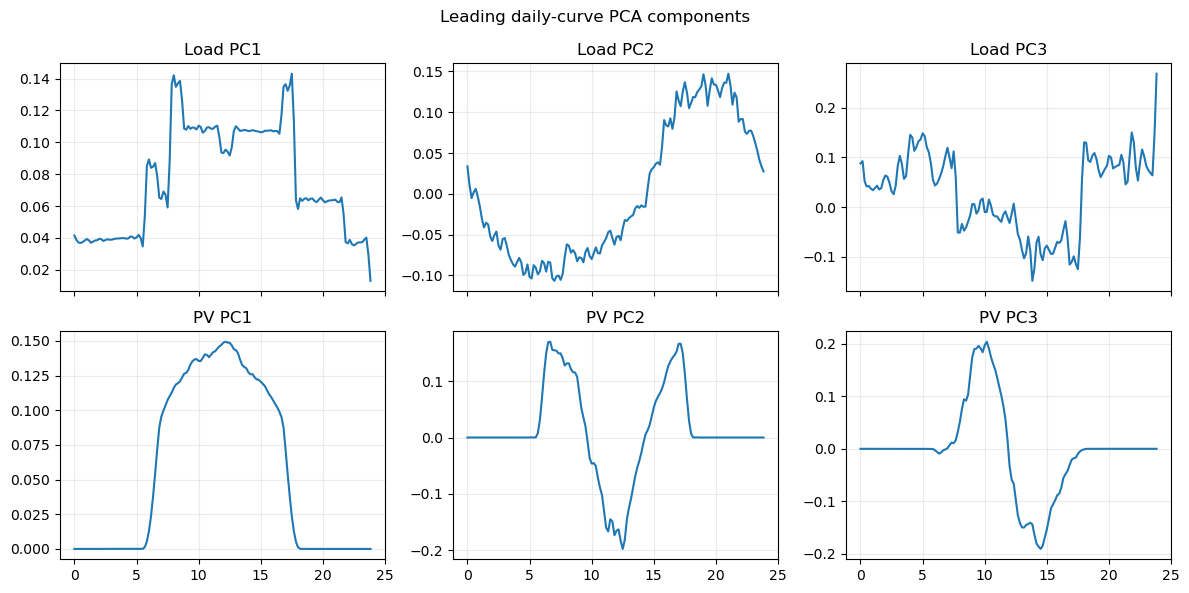

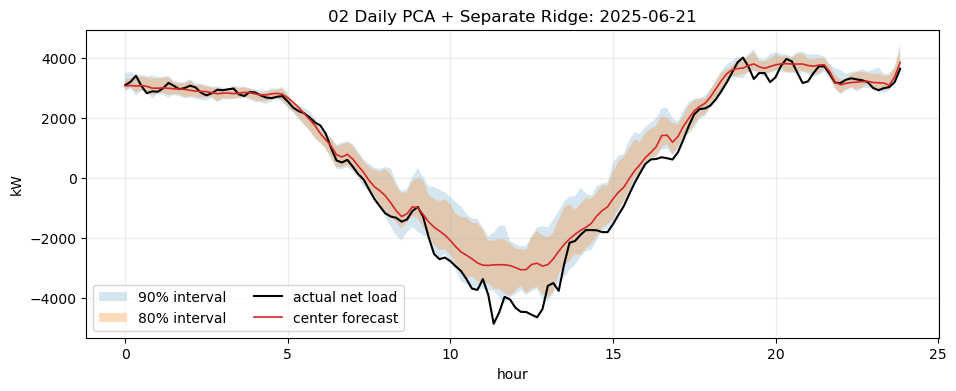

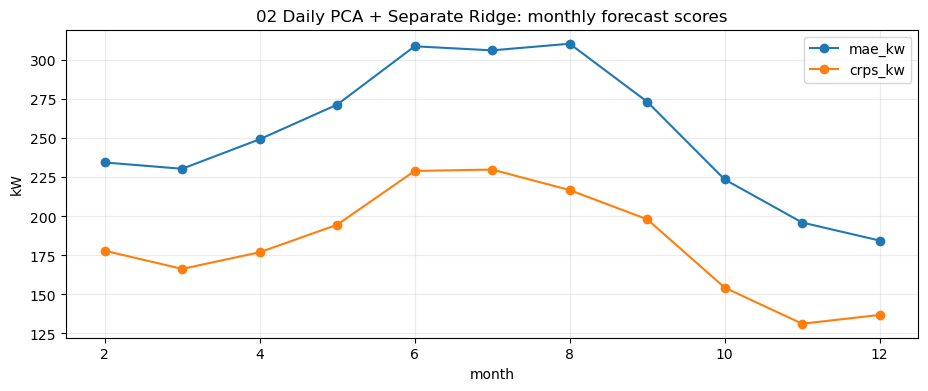

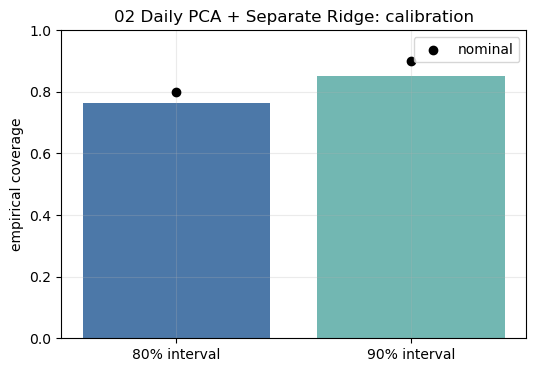

In [4]:
MODEL_NAME="02 Daily PCA + Separate Ridge"

phi_l, phi_p = last_components
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
for i, ax in enumerate(axes[0]): ax.plot(SLOTS/6, phi_l[i]); ax.set_title(f"Load PC{i+1}")
for i, ax in enumerate(axes[1]): ax.plot(SLOTS/6, phi_p[i]); ax.set_title(f"PV PC{i+1}")
fig.suptitle("Leading daily-curve PCA components"); plt.tight_layout(); plt.show()
plot_diagnostics(MODEL_NAME, centres_load, centres_pv, scenario_days, daily, bands)


## 拟合效果汇总

MAE/RMSE 衡量中心预测误差；CRPS 综合衡量整个概率分布，三者越小越好。覆盖率应分别接近 0.8 和 0.9；区间宽度越小表示预测越尖锐。

In [5]:
summary = summary.copy()
summary.insert(0, 'model', MODEL_NAME)
display(summary.round(4))

,model,metric,value
0,02 Daily PCA + Separate Ridge,MAE (kW),253.7556
1,02 Daily PCA + Separate Ridge,RMSE (kW),356.6159
2,02 Daily PCA + Separate Ridge,CRPS (kW),182.9957
3,02 Daily PCA + Separate Ridge,80% coverage,0.7627
4,02 Daily PCA + Separate Ridge,90% coverage,0.8510
5,02 Daily PCA + Separate Ridge,80% width (kW),771.5471
6,02 Daily PCA + Separate Ridge,90% width (kW),972.8526


## 导出预测结果

将评价期内每日 144 个时段的负荷、光伏和净负荷预测，以及净负荷 80%/90% 预测区间导出为 Excel。工作簿同时保留实际值、逐日评价指标和总体指标，便于核验。

In [6]:
from openpyxl.styles import Font, PatternFill

eval_dates = DATES[EVAL_IDX]
forecast_detail = pd.DataFrame({
    'date': np.repeat(eval_dates, len(SLOTS)),
    'slot': np.tile(SLOTS + 1, len(eval_dates)),
    'interval_start': np.repeat(eval_dates.values, len(SLOTS))
                      + pd.to_timedelta(np.tile(SLOTS * 10, len(eval_dates)), unit='m'),
    'actual_load_kw': LOAD[EVAL_IDX].ravel(),
    'forecast_load_kw': centres_load[EVAL_IDX].ravel(),
    'actual_pv_kw': PV[EVAL_IDX].ravel(),
    'forecast_pv_kw': centres_pv[EVAL_IDX].ravel(),
    'actual_net_load_kw': (LOAD[EVAL_IDX] - PV[EVAL_IDX]).ravel(),
    'forecast_net_load_kw': (centres_load[EVAL_IDX] - centres_pv[EVAL_IDX]).ravel(),
    'net_load_p05_kw': bands['q05'].ravel(),
    'net_load_p10_kw': bands['q10'].ravel(),
    'net_load_p90_kw': bands['q90'].ravel(),
    'net_load_p95_kw': bands['q95'].ravel(),
})

output_dir = ROOT / 'q2' / 'results'
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / 'q2_forecast_results.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    forecast_detail.to_excel(writer, sheet_name='Forecast_10min', index=False)
    daily.to_excel(writer, sheet_name='Daily_Metrics', index=False)
    summary.to_excel(writer, sheet_name='Summary', index=False)

    header_fill = PatternFill('solid', fgColor='1F4E78')
    header_font = Font(color='FFFFFF', bold=True)
    widths = {
        'Forecast_10min': [12, 8, 19] + [20] * 10,
        'Daily_Metrics': [13] + [17] * (len(daily.columns) - 1),
        'Summary': [34, 22, 16],
    }
    for sheet_name, worksheet in writer.sheets.items():
        worksheet.freeze_panes = 'A2'
        worksheet.auto_filter.ref = worksheet.dimensions
        worksheet.sheet_view.showGridLines = False
        for cell in worksheet[1]:
            cell.fill = header_fill
            cell.font = header_font
        for column_index, width in enumerate(widths[sheet_name], start=1):
            worksheet.column_dimensions[worksheet.cell(1, column_index).column_letter].width = width

    for cell in writer.sheets['Forecast_10min']['A'][1:]:
        cell.number_format = 'yyyy-mm-dd'
    for cell in writer.sheets['Forecast_10min']['C'][1:]:
        cell.number_format = 'yyyy-mm-dd hh:mm'
    for row in writer.sheets['Forecast_10min'].iter_rows(min_row=2, min_col=4, max_col=13):
        for cell in row:
            cell.number_format = '0.000'
    for cell in writer.sheets['Daily_Metrics']['A'][1:]:
        cell.number_format = 'yyyy-mm-dd'
    for row in writer.sheets['Daily_Metrics'].iter_rows(min_row=2, min_col=2):
        for cell in row:
            cell.number_format = '0.0000'
    for cell in writer.sheets['Summary']['C'][1:]:
        cell.number_format = '0.0000'

print(f'预测结果已导出：{output_path}')
print(f'明细记录数：{len(forecast_detail):,}')

预测结果已导出：/Users/jinyu/workspace/MCM/CUMCM_2026/q2/results/q2_forecast_results.xlsx
明细记录数：48,096
